In [8]:
import sys, os
from datetime import datetime, timedelta
#  DIR path
sys.path.append(os.path.abspath('../lib/demand'))
sys.path.append(os.path.abspath('../lib/cost'))


import pandas as pd
import numpy as np
import importlib
import Environment as env_mod
from inventoryPolices import StandardInventoryPolicy, InventoryPolicyParams


# simulator class
importlib.reload(env_mod)
SimulationConfig = env_mod.SimulationConfig
Simulator = env_mod.Simulator

In [9]:
#- parameter setting -#

# Setting of Demand Generator 
start_time = datetime(2025, 12, 31)     # the start time of demand generation 
end_time = datetime(2026, 12, 31)       # the end time of demand generation
delta_time = 1                          # the interval between two time points
seed = 3                                # random seed number

# Dealer, Truck and Part
n_dealers = 1               # the number of dealers
n_truck_range = [1, 2]     # the range of truck fleet sizes in each dealer 
n_part_range = [1, 2]      # the range of the number of parts constituting truck


In [10]:
#- demand simulation -#
# class: Simulator Configuration
cfg = SimulationConfig(
    start_time = start_time,
    end_time = end_time,
    delta_time = delta_time
)

# class: Simulator
sim = Simulator(
    config=cfg, 
    seed=seed, 
    n_dealers=n_dealers,
    n_truck_range=n_truck_range,
    n_part_range=n_part_range)
events = sim.run()


In [18]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
from collections import deque
from datetime import datetime, timedelta

class SmartInventoryEnv(gym.Env):
    metadata = {'render_modes': ['human']}

    def __init__(self, demand_array, start_date_str, max_inventory=100, max_order=50, lead_time=14, demand_window=7):
        super().__init__()
        
        self.demand_array = np.array(demand_array, dtype=int)
        self.total_days = len(self.demand_array)
        self.start_date = datetime.strptime(start_date_str, '%Y-%m-%d')
        
        self.max_inventory = max_inventory
        self.max_order = max_order
        self.lead_time = lead_time
        self.demand_window = demand_window
        
        #CostTracker variables 
        
        self.holding_cost_rate = 0.15 * 0.13 / 365 # Holding cost rate
        self.order_cost = 100                      # Every order we make there is a cost which is 100
        self.transport_cost_per_unit = 2 * 0.001   # Transport cost Note: This has to be fixed its not correct 
        self.stockout_penalty = 1000  
        
        # Action Space what to order etc {1,2,3..)
        self.action_space = spaces.Box(low=0, high=max_order, shape=(1,), dtype=np.float32)
        
        # Observation Space which in our case is 
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(6,), dtype=np.float32)

    
    def reset(self, seed=None, options=None):
        super().reset(seed=seed)

        
        self.current_day = 0
        self.stock = self.max_inventory // 2 
        self.backorders = 0
        self.demand_history = []
        self.incoming_pipeline = deque([0] * self.lead_time, maxlen=self.lead_time)
        
        # KPI TRACK
        
        self.ep_total_demand = 0
        self.ep_immediate_fulfilled = 0
        self.ep_total_cost = 0.0
        
        return self._get_obs(), {}

    def step(self, action):
        order_qty = int(np.clip(np.round(action[0]), 0, self.max_order))
        
        # 1. TRUCK ARRIVES
        delivery_today = self.incoming_pipeline.popleft()
        self.stock = min(self.max_inventory, self.stock + delivery_today)
        
        if self.backorders > 0 and self.stock > 0:
            fulfilled = min(self.backorders, self.stock)
            self.stock -= fulfilled
            self.backorders -= fulfilled

        # 2. PLACE NEW ORDER
        self.incoming_pipeline.append(order_qty)

        # 3. CUSTOMERS ARRIVE
        demand_today = self.demand_array[self.current_day]
        units_sold = min(self.stock, demand_today) # This is immediate fulfillment!
        unmet_demand = demand_today - units_sold
        
        self.stock -= units_sold
        self.backorders += unmet_demand 
        
        # Update kpi tracker
        self.ep_total_demand += demand_today
        self.ep_immediate_fulfilled += units_sold
        
        # Calculate ISL safely (avoid dividing by zero on days with no demand)
        isl = self.ep_immediate_fulfilled / self.ep_total_demand if self.ep_total_demand > 0 else 1.0
        
        self.demand_history.append(demand_today)
        if len(self.demand_history) > self.demand_window:
            self.demand_history.pop(0)
        
        # 4. Calculating the costs 
        holding_cost = self.stock * self.holding_cost_rate
        stockout_cost = unmet_demand * self.stockout_penalty
        ordering_cost = self.order_cost + (order_qty * self.transport_cost_per_unit) if order_qty > 0 else 0.0
            
        total_daily_cost = holding_cost + stockout_cost + ordering_cost
        self.ep_total_cost += total_daily_cost # Track cumulative cost
        
        # 5. Final step where we increment one day finalzing the reward  and checking so we arent in the end of the loop
        reward = -total_daily_cost
        self.current_day += 1
        done = self.current_day >= self.total_days
        
        # KPI reinforcement agent
        info = {
            "demand": demand_today,
            "order_qty": order_qty,
            "stock": self.stock,
            "daily_cost": total_daily_cost,
            "ep_isl": isl,                  # Current cumulative ISL
            "ep_total_cost": self.ep_total_cost # Current cumulative Cost
        }
        
        return self._get_obs(), reward, done, False, info


    #Basically our states 
    def _get_obs(self):
        pending_qty = sum(self.incoming_pipeline)
        mean_demand = np.mean(self.demand_history) if len(self.demand_history) > 0 else 0.0
        std_demand = np.std(self.demand_history) if len(self.demand_history) > 1 else 0.0
        current_date = self.start_date + timedelta(days=int(self.current_day))
        day_of_year = current_date.timetuple().tm_yday
        return np.array([self.stock, self.backorders, pending_qty, mean_demand, std_demand, day_of_year], dtype=np.float32)

In [19]:
from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import BaseCallback
import pandas as pd
import matplotlib.pyplot as plt

# --- THE AI SPY CALLBACK ---
class TrainingTrackerCallback(BaseCallback):
    """
    Custom callback for plotting the AI's learning curve.
    It extracts the final KPIs at the end of every episode.
    """
    def __init__(self, verbose=0):
        super().__init__(verbose)
        self.episode_rewards = []
        self.episode_costs = []
        self.episode_isls = []
        self.current_ep_reward = 0.0

    def _on_step(self) -> bool:
        # locals["rewards"] holds the reward the AI just got for the current day
        self.current_ep_reward += self.locals["rewards"][0]

        # locals["dones"] is a boolean that becomes True when the episode (dataset) finishes
        if self.locals["dones"][0]:
            # The episode ended! Save the total reward.
            self.episode_rewards.append(self.current_ep_reward)
            self.current_ep_reward = 0.0

            # Extract our custom KPIs from the environment's info dictionary
            info = self.locals["infos"][0]
            if "ep_isl" in info:
                self.episode_isls.append(info["ep_isl"])       # Final ISL for the episode
                self.episode_costs.append(info["ep_total_cost"]) # Final Total Cost
        return True

# 1. Setup the Environment
df = pd.read_csv('../data/demand/demand_series.csv')
demand = df['failure'].values

env = SmartInventoryEnv(
    demand_array=demand, 
    start_date_str='2020-01-01', 
    max_inventory=100, 
    max_order=50, 
    lead_time=14
)

# 2. Initialize the Model and the Callback Tracker
model = PPO("MlpPolicy", env, verbose=0, learning_rate=0.0003)
tracker = TrainingTrackerCallback()

print("Training")
# We train for 100,000 steps to get a really nice, smooth learning curve
model.learn(total_timesteps=100000, callback=tracker)
print(f"Training Complete! Total episodes simulated: {len(tracker.episode_rewards)}")

Starting AI Training with advanced tracking...
Training Complete! Total episodes simulated: 274


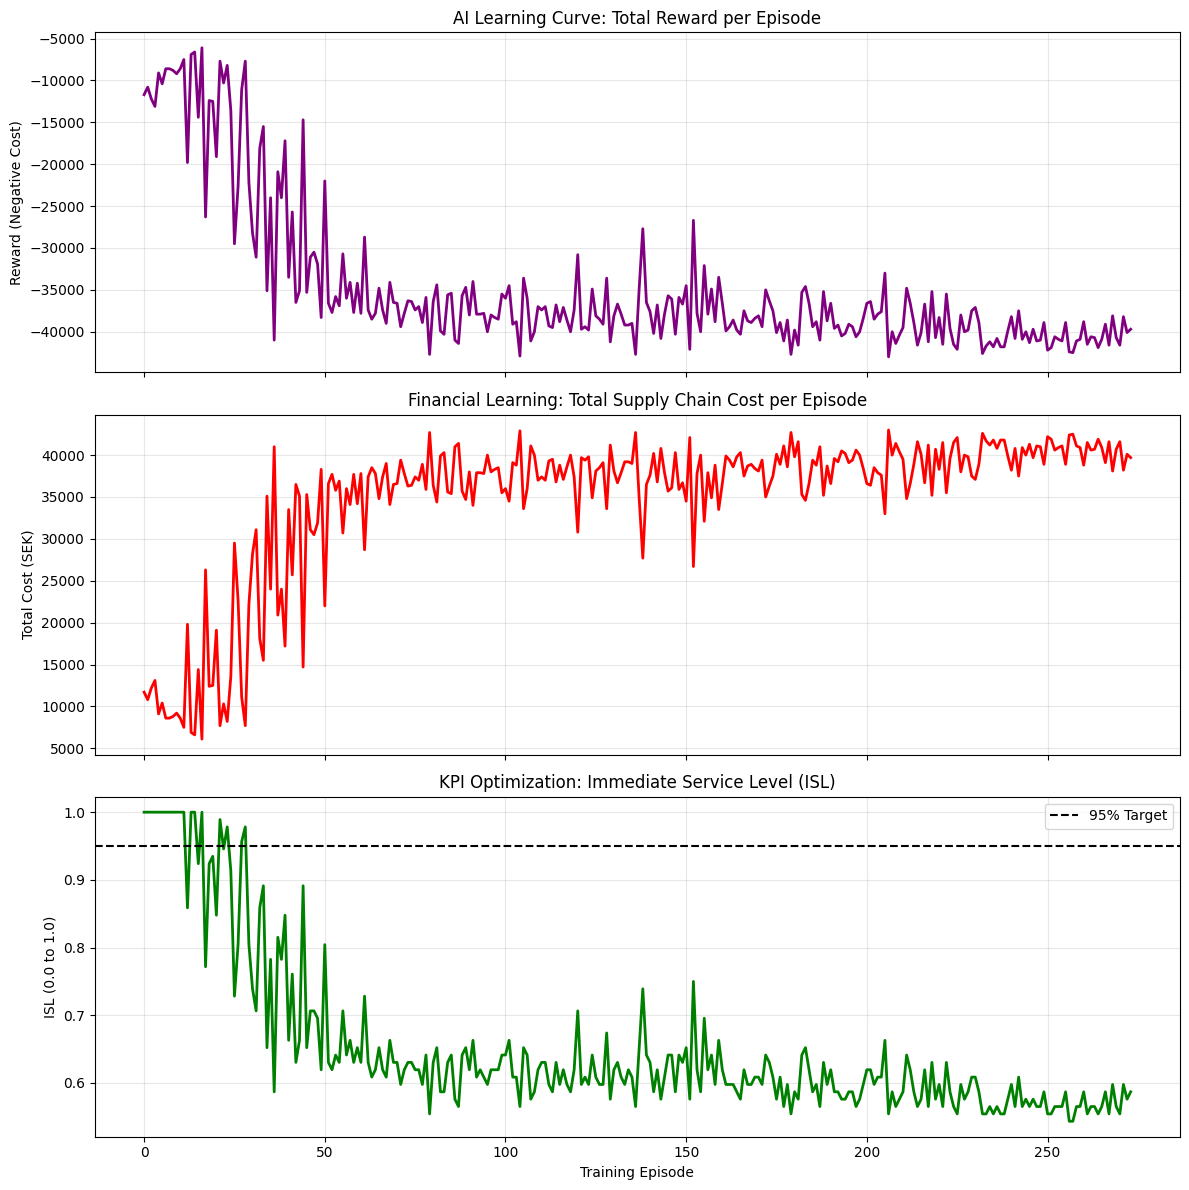

In [16]:
# Learning curves plot

fig, axs = plt.subplots(3, 1, figsize=(12, 12), sharex=True)
episodes = range(len(tracker.episode_rewards))

# Plot 1: Total Reward (The "Score")
axs[0].plot(episodes, tracker.episode_rewards, color="purple", linewidth=2)
axs[0].set_title("AI Learning Curve: Total Reward per Episode")
axs[0].set_ylabel("Reward (Negative Cost)")
axs[0].grid(True, alpha=0.3)

# Plot 2: Total Episode Cost
axs[1].plot(episodes, tracker.episode_costs, color="red", linewidth=2)
axs[1].set_title("Financial Learning: Total Supply Chain Cost per Episode")
axs[1].set_ylabel("Total Cost (SEK)")
axs[1].grid(True, alpha=0.3)

# Plot 3: Immediate Service Level (ISL)
axs[2].plot(episodes, tracker.episode_isls, color="green", linewidth=2)
axs[2].set_title("KPI Optimization: Immediate Service Level (ISL)")
axs[2].set_xlabel("Training Episode")
axs[2].set_ylabel("ISL (0.0 to 1.0)")
axs[2].axhline(y=0.95, color='black', linestyle='--', label='95% Target') # Your target from costTracker
axs[2].legend()
axs[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import pandas as pd
from collections import deque
from datetime import datetime, timedelta
import matplotlib.pyplot as plt

from stable_baselines3 import PPO, SAC, TD3
from stable_baselines3.common.callbacks import BaseCallback

# =========================================================
# 1. LOAD AND FILTER THE 365-DAY DATA
# =========================================================
file_path = '../data/demand/demand_series.csv' # Make sure this path is correct!
df = pd.read_csv(file_path)

# Filter for the exact dealer and part
filtered_df = df[(df['dealer_id'] == 'D00') & (df['part_type'] == 'type0')].copy()
filtered_df = filtered_df.sort_values('time')
clean_demand = filtered_df['failure'].values

print(f"Loaded {len(clean_demand)} days of data.")
print(f"Total parts demanded over the year: {sum(clean_demand)}")

# =========================================================
# 2. DEFINE THE BASE ENVIRONMENT
# =========================================================
class SmartInventoryEnv(gym.Env):
    metadata = {'render_modes': ['human']}

    def __init__(self, demand_array, start_date_str, max_inventory=100, max_order=50, lead_time=14, demand_window=7):
        super().__init__()
        self.demand_array = np.array(demand_array, dtype=int)
        self.total_days = len(self.demand_array)
        self.start_date = datetime.strptime(start_date_str, '%Y-%m-%d')
        
        self.max_inventory = max_inventory
        self.max_order = max_order
        self.lead_time = lead_time
        self.demand_window = demand_window
        
        # Cost Tracker variables
        self.holding_cost_rate = 0.15 * 0.13 / 365 
        self.order_cost = 100                      
        self.transport_cost_per_unit = 2 * 0.001   
        self.stockout_penalty = 1000               
        
        # CONTINUOUS ACTION SPACE (Required for SAC and TD3)
        self.action_space = spaces.Box(low=0, high=max_order, shape=(1,), dtype=np.float32)
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(6,), dtype=np.float32)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.current_day = 0
        self.stock = self.max_inventory // 2 
        self.backorders = 0
        self.demand_history = []
        self.incoming_pipeline = deque([0] * self.lead_time, maxlen=self.lead_time)
        
        self.ep_total_demand = 0
        self.ep_immediate_fulfilled = 0
        self.ep_total_cost = 0.0
        
        return self._get_obs(), {}

    def step(self, action):
        # Round the continuous action from the AI to an integer order quantity
        order_qty = int(np.clip(np.round(action[0]), 0, self.max_order))
        
        # 1. TRUCK ARRIVES
        delivery_today = self.incoming_pipeline.popleft()
        self.stock = min(self.max_inventory, self.stock + delivery_today)
        
        if self.backorders > 0 and self.stock > 0:
            fulfilled = min(self.backorders, self.stock)
            self.stock -= fulfilled
            self.backorders -= fulfilled

        # 2. PLACE NEW ORDER
        self.incoming_pipeline.append(order_qty)

        # 3. CUSTOMERS ARRIVE
        demand_today = self.demand_array[self.current_day]
        units_sold = min(self.stock, demand_today) 
        unmet_demand = demand_today - units_sold
        
        self.stock -= units_sold
        self.backorders += unmet_demand 
        
        self.ep_total_demand += demand_today
        self.ep_immediate_fulfilled += units_sold
        isl = self.ep_immediate_fulfilled / self.ep_total_demand if self.ep_total_demand > 0 else 1.0
        
        self.demand_history.append(demand_today)
        if len(self.demand_history) > self.demand_window:
            self.demand_history.pop(0)
        
        # 4. CALCULATE COSTS
        holding_cost = self.stock * self.holding_cost_rate
        stockout_cost = unmet_demand * self.stockout_penalty
        ordering_cost = self.order_cost + (order_qty * self.transport_cost_per_unit) if order_qty > 0 else 0.0
            
        total_daily_cost = holding_cost + stockout_cost + ordering_cost
        self.ep_total_cost += total_daily_cost 
        
        # 5. FINALIZE STEP
        reward = -total_daily_cost
        self.current_day += 1
        done = self.current_day >= self.total_days
        
        info = {
            "demand": demand_today, "order_qty": order_qty, "stock": self.stock,
            "daily_cost": total_daily_cost, "ep_isl": isl, "ep_total_cost": self.ep_total_cost
        }
        return self._get_obs(), reward, done, False, info

    def _get_obs(self):
        pending_qty = sum(self.incoming_pipeline)
        mean_demand = np.mean(self.demand_history) if len(self.demand_history) > 0 else 0.0
        std_demand = np.std(self.demand_history) if len(self.demand_history) > 1 else 0.0
        current_date = self.start_date + timedelta(days=int(self.current_day))
        day_of_year = current_date.timetuple().tm_yday
        return np.array([self.stock, self.backorders, pending_qty, mean_demand, std_demand, day_of_year], dtype=np.float32)

# =========================================================
# 3. DEFINE THE STRICT ENVIRONMENT
# =========================================================
class StrictSmartInventoryEnv(SmartInventoryEnv):
    def reset(self, seed=None, options=None):
        obs, info = super().reset(seed=seed, options=options)
        # FORCE STARTING STOCK TO 0
        self.stock = 0 
        obs[0] = self.stock
        return obs, info

# =========================================================
# 4. DEFINE THE AI SPY CALLBACK
# =========================================================
class TrainingTrackerCallback(BaseCallback):
    def __init__(self, verbose=0):
        super().__init__(verbose)
        self.episode_rewards, self.episode_costs, self.episode_isls = [], [], []
        self.current_ep_reward = 0.0

    def _on_step(self) -> bool:
        self.current_ep_reward += self.locals["rewards"][0]
        if self.locals["dones"][0]:
            self.episode_rewards.append(self.current_ep_reward)
            self.current_ep_reward = 0.0
            info = self.locals["infos"][0]
            if "ep_isl" in info:
                self.episode_isls.append(info["ep_isl"])
                self.episode_costs.append(info["ep_total_cost"])
        return True

# =========================================================
# 5. THE ALGORITHM SHOWDOWN (TRAINING)
# =========================================================
def make_env():
    return StrictSmartInventoryEnv(
        demand_array=clean_demand, 
        start_date_str='2026-01-01', 
        max_inventory=100, 
        max_order=50, 
        lead_time=14, # SET BACK TO REALISTIC 14 DAYS!
        demand_window=7
    )

ppo_tracker = TrainingTrackerCallback()
sac_tracker = TrainingTrackerCallback()
td3_tracker = TrainingTrackerCallback()

# I increased the timesteps to 150,000 so the AI has enough time to learn the full 365-day pattern
total_steps = 150000 

print("--- Training PPO Agent (Policy Gradient) ---")
model_ppo = PPO("MlpPolicy", make_env(), verbose=0, learning_rate=0.0003)
model_ppo.learn(total_timesteps=total_steps, callback=ppo_tracker)

print("--- Training SAC Agent (Maximum Entropy) ---")
model_sac = SAC("MlpPolicy", make_env(), verbose=0, learning_rate=0.0003, batch_size=256)
model_sac.learn(total_timesteps=total_steps, callback=sac_tracker)

print("--- Training TD3 Agent (Twin Delayed DDPG) ---")
model_td3 = TD3("MlpPolicy", make_env(), verbose=0, learning_rate=0.001, batch_size=256)
model_td3.learn(total_timesteps=total_steps, callback=td3_tracker)

print("\nAll models finished training! Generating comparison graphs...")

# =========================================================
# 6. PLOTTING THE RESULTS
# =========================================================
fig, axs = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

axs[0].plot(ppo_tracker.episode_rewards, label="PPO", color="purple", alpha=0.7)
axs[0].plot(sac_tracker.episode_rewards, label="SAC", color="orange", alpha=0.7)
axs[0].plot(td3_tracker.episode_rewards, label="TD3", color="blue", alpha=0.7)
axs[0].set_title("Algorithm Showdown: Total Reward per Episode (365-Day Cycle)")
axs[0].set_ylabel("Reward (Negative Cost)")
axs[0].legend()
axs[0].grid(True, alpha=0.3)

axs[1].plot(ppo_tracker.episode_isls, label="PPO ISL", color="purple", alpha=0.5)
axs[1].plot(sac_tracker.episode_isls, label="SAC ISL", color="orange", alpha=0.5)
axs[1].plot(td3_tracker.episode_isls, label="TD3 ISL", color="blue", alpha=0.5)
axs[1].set_title("Algorithm Showdown: Immediate Service Level (ISL)")
axs[1].set_xlabel("Training Episode")
axs[1].set_ylabel("ISL (0.0 to 1.0)")
axs[1].axhline(y=0.95, color='black', linestyle='--', label='95% Target')
axs[1].legend()
axs[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Loaded 365 days of data.
Total parts demanded over the year: 92
--- Training PPO Agent (Policy Gradient) ---
--- Training SAC Agent (Maximum Entropy) ---
